#**PASO 1**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

epocas=20


#**PASO 2**

------------------------------
GENERACIÓN DE SERIE TEMPORAL
------------------------------

Creación de dataset secuencial

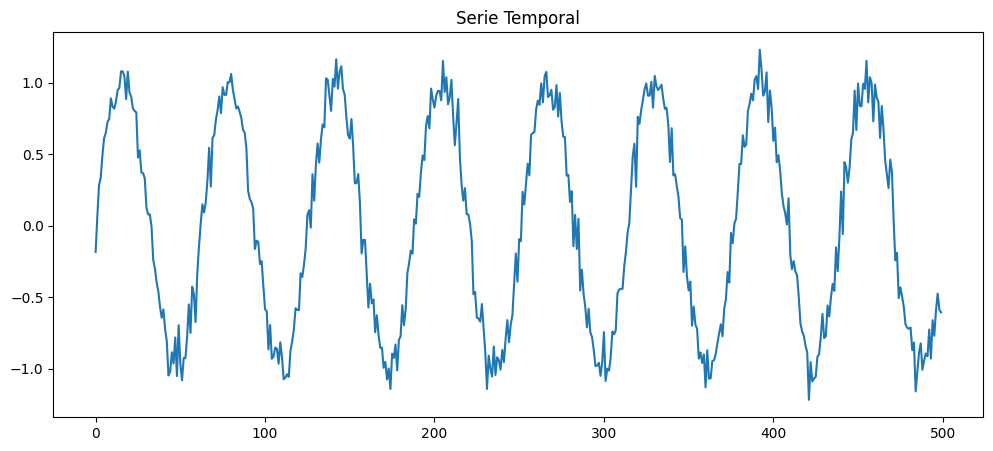

In [6]:
time=np.arange(0, 500)

series=np.sin(0.1 * time) + np.random.normal(scale=0.1, size=len(time))

'''
------------------
Visualización de la serie
------------------
'''

plt.figure(figsize=(12,5))

plt.plot(series)

plt.title("Serie Temporal")

plt.show()

#**PASO 3**

-------------------------
Normalizaciómn de Datos
-------------------------

In [7]:
scaler=MinMaxScaler()

series_scaled=scaler.fit_transform(
    series.reshape(-1,1)
)

#**PASO 4**

-------------------------------
Crear Ventanas Temporales
-------------------------------

In [8]:
#===========================
#FUNCIÓN PARA CREACIÓN DE SECUENCIAS
#===========================

def create_sequences(data, seq_lenght):
    X=[]
    y=[]

    for i in range(len(data) - seq_lenght):
        X.append(
            data[i:i+seq_lenght]
        )

        y.append(
            data[i+seq_lenght]
        )
    return np.array(X), np.array(y)

#===========================
#CREACIÓN DE SECUENCIAS
#===========================

SEQ_LENGTH=20

X, y=create_sequences(
    series_scaled,
    SEQ_LENGTH
)

print(X.shape)
print(y.shape)

(480, 20, 1)
(480, 1)


#**PASO 5**

----------------------
Entrenamiento/Prueba
----------------------

In [9]:
split=int(len(X) * 0.8)

X_train=X[:split]
X_test=X[split:]

y_train=y[:split]
y_test=y[split:]

print(X_train.shape)

(384, 20, 1)


#**PASO 6**

-----------------------
MODELO BASE LSTM
-----------------------

baseline

In [10]:
model_lstm=keras.Sequential([

    layers.LSTM(
        64,
        input_shape=(SEQ_LENGTH,1)
    ),

    layers.Dense(1)
])

#==========================
#COMPILAR
#==========================

model_lstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

#===========================
#ENTENAR
#===========================

history_lstm=model_lstm.fit(

    X_train,
    y_train,

    epochs=epocas,
    batch_size=32,

    validation_data=(X_test, y_test)
)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.1614 - mae: 0.3186 - val_loss: 0.0851 - val_mae: 0.2476
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0540 - mae: 0.1992 - val_loss: 0.0323 - val_mae: 0.1503
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0363 - mae: 0.1657 - val_loss: 0.0283 - val_mae: 0.1454
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0273 - mae: 0.1464 - val_loss: 0.0235 - val_mae: 0.1318
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0211 - mae: 0.1288 - val_loss: 0.0169 - val_mae: 0.1108
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0140 - mae: 0.1039 - val_loss: 0.0097 - val_mae: 0.0826
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0061 - mae: 0.0649 - val_loss: 0.0036 - val_mae: 0.0460
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0027 - mae: 0.0419 - val_loss: 0.0035 - val_mae: 0.0471
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0026 - mae: 0.

#**PASO 7**

----------------------
VISUALIZACIÓN DE LOSS
----------------------


/tmp/ipykernel_4547/5392982.py:7: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend("Train", "Validation")


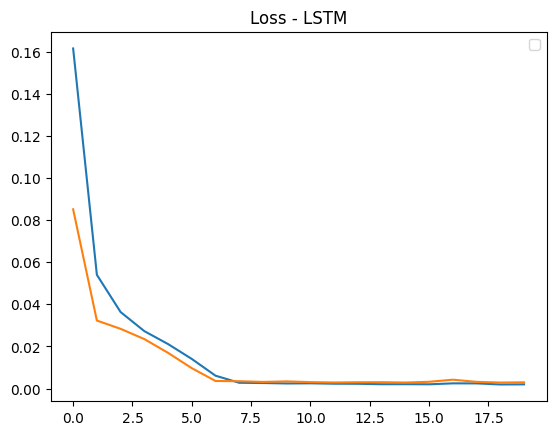

In [11]:
plt.plot(history_lstm.history['loss'])

plt.plot(history_lstm.history['val_loss'])

plt.title("Loss - LSTM")

plt.legend("Train", "Validation")

plt.show()

#**PASO 8**

-----------------------
MODELO DE ATENCIÓN
-----------------------

In [12]:
#=====================
#ENTRADA
#=====================

inputs=keras.Input(
    shape=(SEQ_LENGTH,1)
)

#===========================
#LSTM
#===========================

lstm=layers.LSTM(
    64,
    return_sequences=True
)(inputs)

#=============================
#MECANISMO DE ATENCIÓN
#=============================

attention=layers.Attention()(
    [lstm, lstm]
)

#==============================
#GLOBAL POOLING
#==============================

pool=layers.GlobalAveragePooling1D()(
    attention
)

#===============================
#SALIDA
#===============================

outputs=layers.Dense(1)(pool)

#===============================
#MODELO
#===============================

model_attention=keras.Model(
    inputs,
    outputs
)

#===============================
#COMPILAR
#===============================

model_attention.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

#===============================
#ENTRENAMIENTO
#===============================

history_attention=model_attention.fit(

    X_train,
    y_train,

    epochs=epocas,

    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.1745 - mae: 0.3412 - val_loss: 0.0893 - val_mae: 0.2642
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0903 - mae: 0.2673 - val_loss: 0.0704 - val_mae: 0.2294
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0812 - mae: 0.2520 - val_loss: 0.0694 - val_mae: 0.2288
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0765 - mae: 0.2473 - val_loss: 0.0725 - val_mae: 0.2373
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0752 - mae: 0.2462 - val_loss: 0.0695 - val_mae: 0.2315
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0732 - mae: 0.2427 - val_loss: 0.0692 - val_mae: 0.2316
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0714 - mae: 0.2399 - val_loss: 0.0666 - val_mae: 0.2270
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0689 - mae: 0.2351 - val_loss: 0.0627 - val_mae: 0.2198
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.064

#**PASO 9**

--------------------
MINI TRANSFORMER
--------------------

In [13]:
#=================================
#ENTRADA
#=================================

inputs=keras.Input(
    shape=(SEQ_LENGTH,1)
)

#===================================
#MULTI HEAD ATTENTION
#===================================

attention=layers.MultiHeadAttention(
    num_heads=2,
    key_dim=32
)(
    inputs,
    inputs
)

#====================================
#NORMALIZACIÓN
#====================================

x=layers.LayerNormalization()(
    attention
)

#=====================================
#FLATEN
#=====================================

x=layers.Flatten()(x)

#======================================
#DENSE
#======================================

x=layers.Dense(
    64,
    activation='relu'
)(x)

#======================================
#SALIDA
#======================================

outputs=layers.Dense(1)(x)

#======================================
#MODELO
#======================================

model_transformer=keras.Model(
    inputs,
    outputs
)

#======================================
#COMPILAR
#======================================

model_transformer.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

#=======================================
#ENTRENAMIENTO
#=======================================

history_transformer=model_transformer.fit(

    X_train,
    y_train,
    epochs=epocas,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.3359 - mae: 0.5005 - val_loss: 0.2471 - val_mae: 0.4125
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3242 - mae: 0.4885 - val_loss: 0.2374 - val_mae: 0.4008
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3128 - mae: 0.4766 - val_loss: 0.2281 - val_mae: 0.3895
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3017 - mae: 0.4651 - val_loss: 0.2192 - val_mae: 0.3784
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2911 - mae: 0.4538 - val_loss: 0.2108 - val_mae: 0.3676
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2809 - mae: 0.4427 - val_loss: 0.2026 - val_mae: 0.3573
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2711 - mae: 0.4323 - val_loss: 0.1948 - val_mae: 0.3473
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2616 - mae: 0.4223 - val_loss: 0.1873 - val_mae: 0.3378
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.252

#**PASO 10**

-------------------------
COMPARACIÓN DE MODELOS
-------------------------

In [14]:
#========================================
#EVALUACIÓN
#========================================

print("LSTM")
print(
    model_lstm.evaluate(X_test,y_test)
)

print("\nAttention")
print(
    model_attention.evaluate(X_test, y_test)
)

print("\nTransformer")
print(
    model_transformer.evaluate(X_test, y_test)
)

LSTM
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0029 - mae: 0.0430
[0.002942450577393174, 0.04301599785685539]

Attention
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0064 - mae: 0.0660
[0.006419312208890915, 0.06599991023540497]

Transformer
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1219 - mae: 0.2608
[0.12191545963287354, 0.2608124315738678]


#**PASO 11**

---------------------
VISUALIZACIÓN
---------------------

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step 


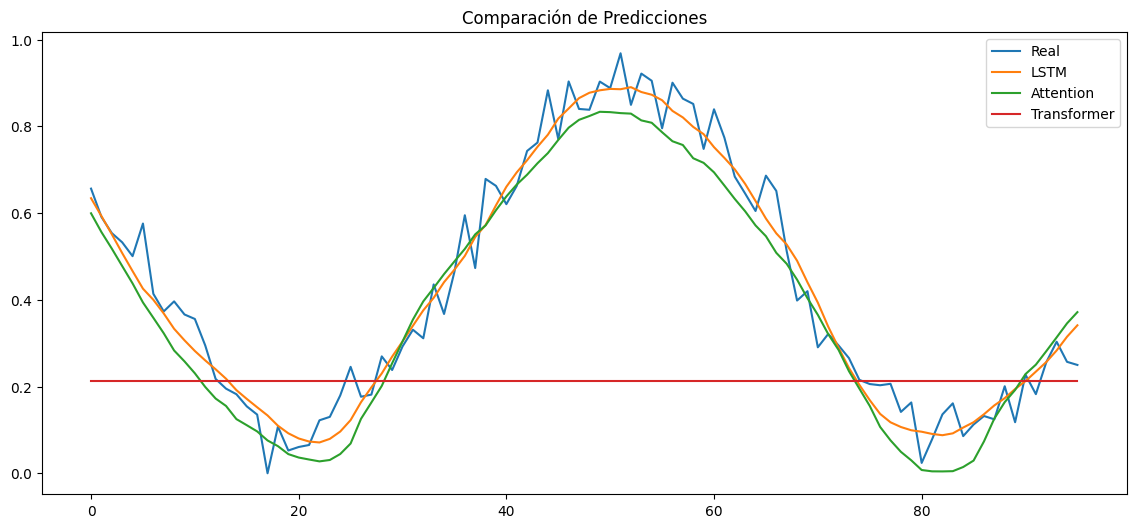

In [15]:
pred_lstm=model_lstm.predict(X_test)

pred_attention=model_attention.predict(X_test)

pred__transformer=model_transformer.predict(X_test)

#=========================================
#GRÁFICA
#=========================================

plt.figure(figsize=(14,6))

plt.plot(y_test, label='Real')

plt.plot(pred_lstm, label='LSTM')

plt.plot(pred_attention, label='Attention')

plt.plot(pred__transformer, label="Transformer")

plt.legend()

plt.title("Comparación de Predicciones")

plt.show()